# 📊 Modélisation Supervisée (Ridge / Lasso / Random Forest) & Feature Importance
## Capstone G10 · Programme FRST/SDMIA · Faculté des Sciences, UEH

**Équipe (Groupe 10) :**
- **Jean Baptiste Kendy** — coordinateur
- **Louis Wilson Junior**
- **Jonathan Francois Alcena**

**Encadrant :** ING Evens Toussaint

---

Ce notebook correspond à la **Phase 2.5 — Modélisation supervisée (Ridge/Lasso/RF) & Feature Importance**.

L'objectif est d'utiliser l'**IIFT** (indice cible construit en Phase 2.2) comme variable à expliquer, et
les **24 variables quantitatives actives** ayant servi à sa construction (Phase 2.2) comme prédicteurs,
pour :
1. **Valider** que l'IIFT est bien (par construction) une combinaison linéaire de ces variables — Ridge/Lasso
   doivent y parvenir avec un score quasi parfait ; c'est un contrôle de cohérence, pas un exploit prédictif.
2. **Identifier un sous-ensemble parcimonieux** de variables suffisant pour reconstruire l'IIFT, via la
   sélection automatique de Lasso (coefficients ramenés à zéro).
3. **Tester une hypothèse de non-linéarité** : un Random Forest capture-t-il une structure que l'ACP
   (linéaire par construction) ne peut pas voir ?
4. **Comparer les importances de variables** entre 4 angles différents (Ridge, Lasso, Random Forest,
   contribution ACP à Dim1) pour identifier les variables dont le rôle est robuste à la méthode utilisée.
5. **Produire un modèle entraîné** (Ridge/RF) utilisable comme calculateur rapide de l'IIFT pour de
   nouvelles communes, sans avoir à refaire l'ACP complète.

> ⚠️ **Lisez la Section 3** avant d'interpréter les résultats de R² : parce que l'IIFT est mathématiquement
> une projection linéaire des variables utilisées ici comme prédicteurs, un score quasi parfait (R² proche
> de 1) pour Ridge/Lasso est **attendu et normal**, pas une preuve de qualité prédictive au sens usuel.

**Fichiers d'entrée attendus sur GitHub :**
- `output/tables/eda_tables/G10_matrice_ACP.csv`
- `output/tables/eda_tables/G10_dictionnaire_ACP.csv`
- `output/tables/acp_iift_tables/G10_iift_communes.csv`
- `output/tables/acp_iift_tables/G10_acp_contributions_variables.csv`

**Fichiers de sortie exportés dans `output/tables/modelisation_tables` :**
- `G10_modelisation_comparaison_modeles.csv`
- `G10_modelisation_importance_variables.csv`
- `G10_modelisation_predictions_communes.csv`
- `G10_modelisation_variables_lasso_retirees.csv`

### Plan du notebook

| Section | Contenu |
|---|---|
| 0 | Installation, imports & configuration graphique |
| 1 | Chargement des données (matrice ACP, dictionnaire ACP, IIFT, contributions) |
| 2 | Fusion & contrôle qualité (X, y) |
| 3 | ⚠️ Note méthodologique — pourquoi un R² quasi parfait est attendu ici |
| 4 | Séparation train/test + validation croisée (K-Fold) |
| 5 | Standardisation des variables |
| 6 | Régression Ridge (RidgeCV) |
| 7 | Régression Lasso (LassoCV) — sélection de variables |
| 8 | Random Forest (recherche d'hyperparamètres + importances) |
| 9 | Comparaison des 3 modèles (métriques) |
| 10 | Comparaison des importances de variables (Ridge / Lasso / RF / ACP) |
| 11 | Prédit vs réel (diagnostic visuel) |
| 12 | Exports (tables + figures HD) |
| 13 | Synthèse méthodologique pour le rapport |

> **Note méthodologique** : ce notebook prend la suite de `G10_ACP_Calcul_Indice_IIFT.ipynb`
> (Phase 2.2, déjà exécuté) — voir sa Section 9 pour le détail de la construction de l'IIFT.


---
## Section 0 (Cellule 1) — Installation, imports & configuration graphique


In [1]:
# ===========================================================================
#  SECTION 0 (Cellule 2) — INSTALLATION, IMPORTS & CONFIGURATION
# ===========================================================================

# Décommentez si nécessaire dans Google Colab.
# !pip install pandas numpy scikit-learn matplotlib seaborn -q

import os
import warnings
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# ── Charte graphique — cohérente avec les notebooks EDA et ACP/IIFT précédents ──
sns.set_theme(style="whitegrid", font_scale=1.0)
COULEUR_PRINCIPALE = "#2C5F7C"   # bleu pétrole — Ridge
COULEUR_ACCENT      = "#C0522D"  # terracotta — Lasso
COULEUR_RF          = "#4C8C4A"  # vert — Random Forest
COULEUR_ACP          = "#8172B2" # violet — référence ACP (contribution Dim1)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
    "figure.dpi": 110,
})

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Graine fixée : reproductibilité du split train/test, de la validation croisée
# et de l'initialisation aléatoire du Random Forest
SEED = 42
np.random.seed(SEED)

DOSSIER_TABLES = Path("output/tables/modelisation_tables")
DOSSIER_FIGURES = Path("output/figures")   # dossier partagé avec les notebooks précédents
DOSSIER_TABLES.mkdir(parents=True, exist_ok=True)
DOSSIER_FIGURES.mkdir(parents=True, exist_ok=True)

print("✅ Imports et configuration réussis")
print(f"   Colab   : {IN_COLAB}")
print(f"   Tables  : {DOSSIER_TABLES.resolve()}")
print(f"   Figures : {DOSSIER_FIGURES.resolve()}")


✅ Imports et configuration réussis
   Colab   : True
   Tables  : /content/output/tables/modelisation_tables
   Figures : /content/output/figures


---
## Section 1 (Cellule 3) — Chargement des données depuis GitHub

Quatre fichiers sont nécessaires, issus des deux notebooks précédents :
- `G10_matrice_ACP.csv` et `G10_dictionnaire_ACP.csv` (Phase EDA — `output/tables/eda_tables`) :
  les 24 variables quantitatives actives, mêmes que celles utilisées pour l'ACP.
- `G10_iift_communes.csv` (Phase 2.2 — `output/tables/acp_iift_tables`) : la variable cible **IIFT**.
- `G10_acp_contributions_variables.csv` (Phase 2.2) : contribution de chaque variable à Dim1,
  utilisée en Section 10 pour comparer les importances de variables entre méthodes.


In [2]:
# ===========================================================================
#  SECTION 1 (Cellule 4) — CHEMINS & CHARGEMENT DES DONNÉES (dépôt GitHub)
# ===========================================================================

RACINE_GITHUB = "https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main"
DOSSIER_GITHUB_EDA = f"{RACINE_GITHUB}/output/tables/eda_tables"
DOSSIER_GITHUB_ACP = f"{RACINE_GITHUB}/output/tables/acp_iift_tables"

CHEMIN_MATRICE_ACP = f"{DOSSIER_GITHUB_EDA}/G10_matrice_ACP.csv"
CHEMIN_DICTIONNAIRE_ACP = f"{DOSSIER_GITHUB_EDA}/G10_dictionnaire_ACP.csv"
CHEMIN_IIFT = f"{DOSSIER_GITHUB_ACP}/G10_iift_communes.csv"
CHEMIN_CONTRIB_ACP = f"{DOSSIER_GITHUB_ACP}/G10_acp_contributions_variables.csv"

print("=" * 65)
print("  SECTION 1 — VÉRIFICATION DES FICHIERS (GitHub)")
print("=" * 65)

fichiers_github = [
    (CHEMIN_MATRICE_ACP, "MATRICE_ACP"),
    (CHEMIN_DICTIONNAIRE_ACP, "DICO_ACP"),
    (CHEMIN_IIFT, "IIFT_COMMUNES"),
    (CHEMIN_CONTRIB_ACP, "CONTRIB_ACP"),
]

# Vérification HEAD (sans télécharger le contenu) avant la lecture réelle :
# message d'erreur clair et immédiat si le dépôt/branche/chemin a changé,
# plutôt qu'une exception brute de pandas plus loin dans la cellule
for chemin, label in fichiers_github:
    try:
        requete = urllib.request.Request(chemin, method="HEAD")
        with urllib.request.urlopen(requete, timeout=15) as reponse:
            taille = int(reponse.headers.get("Content-Length", 0)) / 1024
        print(f"   ✅ {label:<14} accessible ({taille:.1f} Ko) : {chemin}")
    except Exception as e:
        print(f"   ❌ {label:<14} INACCESSIBLE : {chemin}")
        print(f"      → {e}")

matrice_acp = pd.read_csv(CHEMIN_MATRICE_ACP, encoding="utf-8-sig")
dictionnaire_acp = pd.read_csv(CHEMIN_DICTIONNAIRE_ACP, encoding="utf-8-sig")
iift_communes = pd.read_csv(CHEMIN_IIFT, encoding="utf-8-sig")
contrib_acp = pd.read_csv(CHEMIN_CONTRIB_ACP, encoding="utf-8-sig")

print()
print(f"✅ Matrice ACP      : {matrice_acp.shape[0]} communes × {matrice_acp.shape[1]} colonnes")
print(f"✅ Dictionnaire ACP : {dictionnaire_acp.shape[0]} variables")
print(f"✅ IIFT communes    : {iift_communes.shape[0]} communes × {iift_communes.shape[1]} colonnes")
print(f"✅ Contributions ACP: {contrib_acp.shape[0]} lignes")

display(matrice_acp.head(3))
display(iift_communes.head(3))


  SECTION 1 — VÉRIFICATION DES FICHIERS (GitHub)
   ✅ MATRICE_ACP    accessible (41.1 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/eda_tables/G10_matrice_ACP.csv
   ✅ DICO_ACP       accessible (4.0 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/eda_tables/G10_dictionnaire_ACP.csv
   ✅ IIFT_COMMUNES  accessible (14.1 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/acp_iift_tables/G10_iift_communes.csv
   ✅ CONTRIB_ACP    accessible (12.1 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/acp_iift_tables/G10_acp_contributions_variables.csv

✅ Matrice ACP      : 140 communes × 28 colonnes
✅ Dictionnaire ACP : 24 variables
✅ IIFT communes    : 140 communes × 8 colonnes
✅ Contributions ACP: 24 lignes


,id_commune,nom_commune,arrondissement,adm2_pcode,brh_maison_de_transfert,brh_agent_non_bancaire,brh_banque,brh_atm,brh_microfinance,brh_caisse_populaire,population_totale,superficie_km2,superficie_urbaine_km2,taux_compte_formel,taux_compte_mobile,taux_utilisation_OTA,score_connaissance_fka,taux_connaissance_banque,taux_satisfaction_banque,taux_epargne_formelle,taux_telephone_mobile,taux_internet,indice_privation_spatiale,part_urbaine,densite_hab_km2,densite_bancaire_10k,nb_types_services,taille_moyenne_menage
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,4.941642,5.517453,3.135494,3.433987,2.833213,1.945910,13.804902,3.611998,3.269189,20.86,7.19,55.06,4.00,91.20,49.72,15.34,84.34,29.75,0.276,0.99898,10.220308,1.733277,6,4.638888
1,C-002,Delmas,Port-au-Prince,HT0112,5.129899,5.220356,3.258097,3.637586,2.197225,1.098612,12.889480,3.358290,3.358290,21.11,6.17,52.73,3.92,95.03,59.55,18.04,77.00,56.33,0.492,1.00000,9.566672,2.459911,6,4.730436
2,C-003,Cité Soleil,Port-au-Prince,HT0117,2.302585,3.091042,1.098612,0.693147,1.098612,0.693147,12.490078,3.127199,3.127199,21.48,6.72,60.39,4.48,96.25,84.06,15.83,77.48,40.53,0.930,1.00000,9.407788,0.856531,6,4.470211


,id_commune,nom_commune,arrondissement,adm2_pcode,score_acp_dim1_oriente,IIFT,classe_IIFT,IIFT_multi_axes_robustesse
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,10.041542,100.000000,Très élevé,96.904195
1,C-002,Delmas,Port-au-Prince,HT0112,9.727956,97.736443,Très élevé,100.000000
2,C-003,Cité Soleil,Port-au-Prince,HT0117,4.425251,59.459939,Très élevé,71.806599


---
## Section 2 (Cellule 5) — Fusion & contrôle qualité (X, y)


In [3]:
# ===========================================================================
#  SECTION 2 (Cellule 6) — FUSION & CONTRÔLE QUALITÉ
# ===========================================================================

print("=" * 65)
print("  SECTION 2 — FUSION MATRICE ACP + IIFT")
print("=" * 65)

ID_CANDIDATS = ["id_commune", "nom_commune", "arrondissement", "adm2_pcode", "departement"]
cols_id = [c for c in ID_CANDIDATS if c in matrice_acp.columns]

vars_acp = [v for v in dictionnaire_acp["variable"].tolist() if v in matrice_acp.columns]
print(f"Identifiants détectés : {cols_id}")
print(f"Variables prédictives (mêmes que l'ACP) : {len(vars_acp)}")

# Fusion 1:1 sur id_commune — indicator="_merge" permet de repérer explicitement
# toute commune présente d'un côté mais pas de l'autre, plutôt que de laisser
# un merge silencieux introduire des NaN
donnees = matrice_acp.merge(
    iift_communes[["id_commune", "IIFT", "classe_IIFT", "score_acp_dim1_oriente"]],
    on="id_commune", how="inner", validate="1:1", indicator=True,
)
n_non_apparies = (donnees["_merge"] != "both").sum()
donnees = donnees.drop(columns="_merge")

print(f"\n✅ Fusion : {donnees.shape[0]} communes ({n_non_apparies} non appariée(s) — devrait être 0)")
if n_non_apparies > 0:
    raise ValueError(f"{n_non_apparies} commune(s) non appariée(s) entre matrice ACP et IIFT — "
                      f"vérifier que les deux fichiers proviennent bien de la même exécution.")

# ── Contrôle qualité minimal (les deux fichiers sont déjà nettoyés en amont,
#    ceci est un garde-fou, pas un traitement) ────────────────────────────────
n_na = donnees[vars_acp + ["IIFT"]].isna().sum().sum()
n_dup = donnees["id_commune"].duplicated().sum()
print(f"Valeurs manquantes (X + y) : {n_na}")
print(f"Doublons sur id_commune    : {n_dup}")
if n_na > 0 or n_dup > 0:
    raise ValueError("Données non conformes (valeurs manquantes ou doublons) — "
                      "vérifier les notebooks en amont avant de poursuivre.")

# ── Définition des matrices X (prédicteurs) et y (cible) ────────────────────
X = donnees[vars_acp].copy()
y = donnees["IIFT"].copy()

print(f"\n📐 X : {X.shape[0]} communes × {X.shape[1]} variables prédictives")
print(f"📐 y : IIFT, plage [{y.min():.1f}, {y.max():.1f}], moyenne {y.mean():.1f}")
display(donnees[cols_id + ["IIFT", "classe_IIFT"]].head())


  SECTION 2 — FUSION MATRICE ACP + IIFT
Identifiants détectés : ['id_commune', 'nom_commune', 'arrondissement', 'adm2_pcode']
Variables prédictives (mêmes que l'ACP) : 24

✅ Fusion : 140 communes (0 non appariée(s) — devrait être 0)
Valeurs manquantes (X + y) : 0
Doublons sur id_commune    : 0

📐 X : 140 communes × 24 variables prédictives
📐 y : IIFT, plage [0.0, 100.0], moyenne 27.5


,id_commune,nom_commune,arrondissement,adm2_pcode,IIFT,classe_IIFT
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,100.000000,Très élevé
1,C-002,Delmas,Port-au-Prince,HT0112,97.736443,Très élevé
2,C-003,Cité Soleil,Port-au-Prince,HT0117,59.459939,Très élevé
3,C-004,Tabarre,Port-au-Prince,HT0118,71.442514,Très élevé
4,C-005,Carrefour,Port-au-Prince,HT0113,86.218616,Très élevé


---
## Section 3 (Cellule 7) — ⚠️ Note méthodologique : pourquoi un R² quasi parfait est attendu ici

**Ce n'est pas un exercice de prédiction au sens usuel — c'est un exercice de validation et de
parcimonie.** À bien comprendre avant d'interpréter les résultats des sections suivantes.

**Le fait mathématique :** l'IIFT (Phase 2.2) est construit comme `signe × Dim1`, où `Dim1` est une
**combinaison linéaire exacte** des 24 variables de `X` (les coordonnées de l'ACP sur le premier axe sont,
par définition, `X_standardisé @ vecteur_propre_1`). Puis l'IIFT est simplement remis à l'échelle 0-100
(transformation monotone). Autrement dit : **y est presque exactement une fonction linéaire de X, par
construction, avant même qu'aucun modèle ne soit entraîné.**

**Conséquence attendue :** Ridge et Lasso, qui sont des modèles linéaires, devraient donc atteindre un
**R² très proche de 1** (typiquement > 0.98) sur ces données. Ce n'est **pas** un signe de modèle
exceptionnel ni de fuite de données au sens classique (le pipeline train/test est propre) — c'est la
conséquence directe et attendue de la façon dont la cible a été fabriquée.

**Ce que cet exercice apporte alors réellement (et qui justifie de le faire quand même) :**

| # | Ce qu'on apprend | Section |
|---|---|---|
| 1 | **Confirmation/robustesse** : un R² élevé mais < 1 confirmerait que l'IIFT n'est pas *parfaitement* reconstructible par ces 24 variables seules (petits écarts liés à l'arrondi, au split train/test, etc.) — utile comme contrôle de cohérence de la Phase 2.2 | 6-7 |
| 2 | **Parcimonie** : Lasso ramène à zéro les coefficients des variables les moins utiles à la reconstruction de l'IIFT — combien de variables *suffisent* réellement, sur les 24 ? | 7 |
| 3 | **Test de non-linéarité** : le Random Forest, contrairement à Ridge/Lasso, peut capturer des interactions et seuils non-linéaires. Si son R² est similaire à Ridge/Lasso, cela confirme que la structure est bien linéaire (cohérent avec le choix de l'ACP en 2.2). S'il diffère notablement, cela mériterait discussion. | 8 |
| 4 | **Cohérence des importances** : comparer les coefficients Ridge/Lasso, les importances du Random Forest, et les contributions ACP à Dim1 (Phase 2.2) — si les 4 méthodes s'accordent sur les variables clés, c'est un argument de robustesse fort pour le rapport | 10 |
| 5 | **Modèle portable** : une fois entraîné, Ridge/RF permet de calculer l'IIFT d'une commune sans refaire l'ACP complète (utile pour des données futures, ex. millésime 2025+) | 6, 8, 12 |

**En résumé pour la rédaction du rapport :** ne présentez pas le R² élevé comme une performance
prédictive à célébrer — présentez-le comme **la confirmation attendue que l'IIFT est bien linéaire dans
ces variables**, et mettez l'accent sur les points 2 à 4 ci-dessus, qui sont les vrais apports de cette
phase.


---
## Section 4 (Cellule 8) — Séparation train/test + validation croisée (K-Fold)

Avec seulement 140 communes, un simple split train/test (80/20 → 28 communes de test) donne une
estimation de performance assez instable (un seul tirage). On combine donc :
- un **split train/test unique** (80/20, stratifié sur `classe_IIFT` pour préserver la répartition des
  5 classes dans les deux ensembles), utilisé pour les diagnostics visuels (Sections 9-11) ;
- une **validation croisée à 5 plis (K-Fold)**, répétée sur l'ensemble des données, pour une estimation
  plus robuste de la performance de généralisation (Sections 6-9).


In [4]:
# ===========================================================================
#  SECTION 4 (Cellule 9) — SPLIT TRAIN/TEST & K-FOLD
# ===========================================================================

print("=" * 65)
print("  SECTION 4 — SÉPARATION TRAIN/TEST & VALIDATION CROISÉE")
print("=" * 65)

# Stratification sur classe_IIFT (5 classes) plutôt que sur y continu : préserve
# la répartition des communes "Très faible" à "Très élevé" dans train ET test
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, donnees.index, test_size=0.2, random_state=SEED,
    stratify=donnees["classe_IIFT"],
)

print(f"Train : {X_train.shape[0]} communes   Test : {X_test.shape[0]} communes")
print("\nRépartition des classes IIFT (train vs test) :")
comparaison_strat = pd.concat([
    donnees.loc[idx_train, "classe_IIFT"].value_counts(normalize=True).rename("train"),
    donnees.loc[idx_test, "classe_IIFT"].value_counts(normalize=True).rename("test"),
], axis=1).round(3)
display(comparaison_strat)

# 5 plis, mélangés (shuffle=True) car les communes sont ordonnées par id_commune
# dans le fichier source, pas aléatoirement — sans shuffle, les plis seraient biaisés
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"\n✅ K-Fold configuré : {kfold.get_n_splits()} plis, shuffle=True, seed={SEED}")


  SECTION 4 — SÉPARATION TRAIN/TEST & VALIDATION CROISÉE
Train : 112 communes   Test : 28 communes

Répartition des classes IIFT (train vs test) :


,train,test
classe_IIFT,,
Moyen,0.205,0.179
Élevé,0.205,0.179
Faible,0.196,0.214
Très faible,0.196,0.214
Très élevé,0.196,0.214



✅ K-Fold configuré : 5 plis, shuffle=True, seed=42


---
## Section 5 (Cellule 10) — Standardisation des variables

Ridge et Lasso pénalisent la taille des coefficients : sans standardisation, une variable à grande échelle
(ex. `population_totale`) recevrait mécaniquement un coefficient plus petit qu'une variable à petite échelle
(ex. un taux en %), sans que cela reflète une différence réelle d'importance. Le Random Forest n'a pas
besoin de standardisation (il ne compare pas les échelles de coefficients), mais on réutilise les mêmes
`X_train_std`/`X_test_std` pour rester cohérent — cela ne change rien à ses résultats.

**Le scaler est ajusté (`fit`) uniquement sur le train**, puis appliqué (`transform`) au train et au test —
règle de base pour éviter que des informations du test ne fuient dans la standardisation du train.


In [5]:
# ===========================================================================
#  SECTION 5 (Cellule 11) — STANDARDISATION
# ===========================================================================

scaler = StandardScaler()
X_train_std = pd.DataFrame(scaler.fit_transform(X_train), columns=vars_acp, index=X_train.index)
X_test_std  = pd.DataFrame(scaler.transform(X_test),      columns=vars_acp, index=X_test.index)

# Version standardisée de X entier (utile pour la validation croisée en Sections 6-8,
# qui re-découpe train/validation à chaque pli plutôt que de réutiliser X_train/X_test)
X_std = pd.DataFrame(scaler.fit_transform(X), columns=vars_acp, index=X.index)

print("✅ Standardisation effectuée (moyenne 0, écart-type 1 sur le train)")
display(X_train_std.describe().loc[["mean", "std"]].T.head())


✅ Standardisation effectuée (moyenne 0, écart-type 1 sur le train)


,mean,std
brh_maison_de_transfert,2.061843e-16,1.004494
brh_agent_non_bancaire,1.823938e-16,1.004494
brh_banque,-3.172066e-17,1.004494
brh_atm,-1.586033e-17,1.004494
brh_microfinance,1.586033e-17,1.004494


---
## Section 6 (Cellule 12) — Régression Ridge (RidgeCV)

`RidgeCV` teste automatiquement une grille de valeurs de α (force de la pénalisation L2) par validation
croisée interne, et retient la meilleure — pas besoin de `GridSearchCV` séparé pour ce modèle.


In [6]:
# ===========================================================================
#  SECTION 6 (Cellule 13) — RÉGRESSION RIDGE
# ===========================================================================

print("=" * 65)
print("  SECTION 6 — RÉGRESSION RIDGE (RidgeCV)")
print("=" * 65)

grille_alphas = np.logspace(-3, 3, 50)  # de 0.001 à 1000, échelle logarithmique
ridge = RidgeCV(alphas=grille_alphas, cv=kfold)
ridge.fit(X_train_std, y_train)

pred_train_ridge = ridge.predict(X_train_std)
pred_test_ridge  = ridge.predict(X_test_std)

def calculer_metriques(y_vrai, y_pred):
    return {
        "R2":   r2_score(y_vrai, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_vrai, y_pred)),
        "MAE":  mean_absolute_error(y_vrai, y_pred),
    }

metriques_ridge_train = calculer_metriques(y_train, pred_train_ridge)
metriques_ridge_test  = calculer_metriques(y_test, pred_test_ridge)

# Validation croisée à 5 plis sur l'ensemble des données (via Pipeline pour que
# la standardisation soit refaite à chaque pli — évite toute fuite du split CV
# dans le calcul de la moyenne/écart-type du scaler)
from sklearn.pipeline import make_pipeline
pipeline_ridge_cv = make_pipeline(StandardScaler(), RidgeCV(alphas=grille_alphas, cv=5))
scores_cv_ridge = cross_val_score(pipeline_ridge_cv, X, y, cv=kfold, scoring="r2")

print(f"α retenu par validation croisée : {ridge.alpha_:.4f}")
print(f"\nTrain — R²={metriques_ridge_train['R2']:.4f}  RMSE={metriques_ridge_train['RMSE']:.2f}  MAE={metriques_ridge_train['MAE']:.2f}")
print(f"Test  — R²={metriques_ridge_test['R2']:.4f}  RMSE={metriques_ridge_test['RMSE']:.2f}  MAE={metriques_ridge_test['MAE']:.2f}")
print(f"CV (5 plis) — R² moyen={scores_cv_ridge.mean():.4f} (± {scores_cv_ridge.std():.4f})")

coefficients_ridge = pd.Series(ridge.coef_, index=vars_acp, name="coef_ridge").sort_values(key=abs, ascending=False)
print(f"\nTop 10 coefficients Ridge (valeur absolue) :")
display(coefficients_ridge.head(10))


  SECTION 6 — RÉGRESSION RIDGE (RidgeCV)
α retenu par validation croisée : 0.0010

Train — R²=1.0000  RMSE=0.00  MAE=0.00
Test  — R²=1.0000  RMSE=0.00  MAE=0.00
CV (5 plis) — R² moyen=1.0000 (± 0.0000)

Top 10 coefficients Ridge (valeur absolue) :


,coef_ridge
brh_maison_de_transfert,2.114375
brh_banque,2.098133
brh_atm,2.069115
brh_microfinance,2.051596
nb_types_services,2.006739
brh_agent_non_bancaire,1.973612
part_urbaine,1.819300
population_totale,1.805461
superficie_urbaine_km2,1.777446
densite_hab_km2,1.556466


---
## Section 7 (Cellule 14) — Régression Lasso (LassoCV) — sélection de variables

Contrairement à Ridge (pénalisation L2, réduit les coefficients sans jamais les annuler), Lasso
(pénalisation L1) peut ramener certains coefficients **exactement à zéro** — c'est ce qui permet de
répondre à la question de parcimonie posée en Section 3 : combien de variables, parmi les 24, sont
réellement nécessaires pour reconstruire l'IIFT ?


In [7]:
# ===========================================================================
#  SECTION 7 (Cellule 15) — RÉGRESSION LASSO
# ===========================================================================

print("=" * 65)
print("  SECTION 7 — RÉGRESSION LASSO (LassoCV)")
print("=" * 65)

lasso = LassoCV(alphas=None, n_alphas=100, cv=kfold, random_state=SEED, max_iter=10_000)
lasso.fit(X_train_std, y_train)

pred_train_lasso = lasso.predict(X_train_std)
pred_test_lasso  = lasso.predict(X_test_std)

metriques_lasso_train = calculer_metriques(y_train, pred_train_lasso)
metriques_lasso_test  = calculer_metriques(y_test, pred_test_lasso)

pipeline_lasso_cv = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=SEED, max_iter=10_000))
scores_cv_lasso = cross_val_score(pipeline_lasso_cv, X, y, cv=kfold, scoring="r2")

print(f"α retenu par validation croisée : {lasso.alpha_:.4f}")
print(f"\nTrain — R²={metriques_lasso_train['R2']:.4f}  RMSE={metriques_lasso_train['RMSE']:.2f}  MAE={metriques_lasso_train['MAE']:.2f}")
print(f"Test  — R²={metriques_lasso_test['R2']:.4f}  RMSE={metriques_lasso_test['RMSE']:.2f}  MAE={metriques_lasso_test['MAE']:.2f}")
print(f"CV (5 plis) — R² moyen={scores_cv_lasso.mean():.4f} (± {scores_cv_lasso.std():.4f})")

coefficients_lasso = pd.Series(lasso.coef_, index=vars_acp, name="coef_lasso").sort_values(key=abs, ascending=False)
variables_retirees_lasso = coefficients_lasso[coefficients_lasso == 0].index.tolist()
variables_conservees_lasso = coefficients_lasso[coefficients_lasso != 0].index.tolist()

print(f"\n📊 Variables conservées par Lasso : {len(variables_conservees_lasso)} / {len(vars_acp)}")
print(f"📊 Variables ramenées à zéro (jugées non nécessaires) : {len(variables_retirees_lasso)}")
if variables_retirees_lasso:
    print(f"   → {variables_retirees_lasso}")

print(f"\nTop 10 coefficients Lasso (valeur absolue) :")
display(coefficients_lasso.head(10))

tbl_variables_lasso_retirees = pd.DataFrame({"variable": variables_retirees_lasso})


  SECTION 7 — RÉGRESSION LASSO (LassoCV)
α retenu par validation croisée : 0.0195

Train — R²=1.0000  RMSE=0.07  MAE=0.05
Test  — R²=1.0000  RMSE=0.09  MAE=0.07
CV (5 plis) — R² moyen=1.0000 (± 0.0000)

📊 Variables conservées par Lasso : 23 / 24
📊 Variables ramenées à zéro (jugées non nécessaires) : 1
   → ['superficie_km2']

Top 10 coefficients Lasso (valeur absolue) :


,coef_lasso
brh_maison_de_transfert,2.252173
brh_agent_non_bancaire,2.224877
brh_atm,2.107044
brh_microfinance,2.055156
nb_types_services,2.052733
brh_banque,2.051332
population_totale,1.898857
part_urbaine,1.808324
superficie_urbaine_km2,1.772676
taux_epargne_formelle,1.576125


---
## Section 8 (Cellule 16) — Random Forest (hyperparamètres + importances)

Contrairement à Ridge/Lasso, le Random Forest peut capturer des relations non-linéaires et des
interactions entre variables. Avec seulement 140 communes, une grille d'hyperparamètres **volontairement
restreinte** est utilisée (peu de valeurs testées) pour limiter le risque de surapprentissage de la
recherche elle-même sur un aussi petit jeu de données.

Deux mesures d'importance sont calculées :
- **Importance par impureté** (native à `RandomForestRegressor`) : rapide, mais connue pour biaiser en
  faveur des variables à haute cardinalité/variance — à utiliser avec prudence.
- **Importance par permutation** (sur le test uniquement) : mélange aléatoirement chaque variable et
  mesure la dégradation du R² — plus fiable, mais plus coûteuse en calcul.


In [8]:
# ===========================================================================
#  SECTION 8 (Cellule 17) — RANDOM FOREST
# ===========================================================================

print("=" * 65)
print("  SECTION 8 — RANDOM FOREST")
print("=" * 65)

grille_rf = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 3, 5],
}

rf_base = RandomForestRegressor(random_state=SEED)
recherche_rf = GridSearchCV(rf_base, grille_rf, cv=kfold, scoring="r2", n_jobs=-1)
# Random Forest n'a pas besoin de standardisation, mais on réutilise X_train_std
# par cohérence avec Ridge/Lasso (résultat strictement identique à X_train brut)
recherche_rf.fit(X_train_std, y_train)

rf = recherche_rf.best_estimator_
print(f"Meilleurs hyperparamètres (CV) : {recherche_rf.best_params_}")

pred_train_rf = rf.predict(X_train_std)
pred_test_rf  = rf.predict(X_test_std)

metriques_rf_train = calculer_metriques(y_train, pred_train_rf)
metriques_rf_test  = calculer_metriques(y_test, pred_test_rf)

scores_cv_rf = cross_val_score(recherche_rf.best_estimator_, X_std, y, cv=kfold, scoring="r2")

print(f"\nTrain — R²={metriques_rf_train['R2']:.4f}  RMSE={metriques_rf_train['RMSE']:.2f}  MAE={metriques_rf_train['MAE']:.2f}")
print(f"Test  — R²={metriques_rf_test['R2']:.4f}  RMSE={metriques_rf_test['RMSE']:.2f}  MAE={metriques_rf_test['MAE']:.2f}")
print(f"CV (5 plis) — R² moyen={scores_cv_rf.mean():.4f} (± {scores_cv_rf.std():.4f})")

# ── Importance par impureté (native, rapide mais biaisée à haute cardinalité) ──
importance_impurete_rf = pd.Series(rf.feature_importances_, index=vars_acp, name="importance_impurete").sort_values(ascending=False)

# ── Importance par permutation (sur le test, plus fiable) ───────────────────
resultat_permutation = permutation_importance(
    rf, X_test_std, y_test, n_repeats=30, random_state=SEED, scoring="r2"
)
importance_permutation_rf = pd.Series(
    resultat_permutation.importances_mean, index=vars_acp, name="importance_permutation"
).sort_values(ascending=False)

print(f"\nTop 10 — importance par impureté :")
display(importance_impurete_rf.head(10))
print(f"\nTop 10 — importance par permutation (test, 30 répétitions) :")
display(importance_permutation_rf.head(10))


  SECTION 8 — RANDOM FOREST
Meilleurs hyperparamètres (CV) : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}

Train — R²=0.9934  RMSE=1.81  MAE=1.28
Test  — R²=0.9342  RMSE=5.28  MAE=3.74
CV (5 plis) — R² moyen=0.9497 (± 0.0178)

Top 10 — importance par impureté :


,importance_impurete
nb_types_services,0.333300
brh_banque,0.273227
taux_epargne_formelle,0.077042
brh_maison_de_transfert,0.059208
brh_agent_non_bancaire,0.052223
brh_atm,0.037259
part_urbaine,0.037178
taux_internet,0.027043
brh_microfinance,0.022673
population_totale,0.017945



Top 10 — importance par permutation (test, 30 répétitions) :


,importance_permutation
nb_types_services,0.260339
brh_banque,0.086709
brh_maison_de_transfert,0.040808
taux_epargne_formelle,0.036067
brh_agent_non_bancaire,0.017734
brh_atm,0.017581
part_urbaine,0.011700
superficie_urbaine_km2,0.010327
population_totale,0.007151
taux_internet,0.005998


---
## Section 9 (Cellule 18) — Comparaison des 3 modèles


  SECTION 9 — COMPARAISON DES MODÈLES


,modele,R2_train,R2_test,RMSE_test,MAE_test,R2_CV_moyen,R2_CV_ecart_type
0,Ridge,1.0000,1.0000,0.0001,0.0000,1.0000,0.0000
1,Lasso,1.0000,1.0000,0.0861,0.0665,1.0000,0.0000
2,Random Forest,0.9934,0.9342,5.2838,3.7423,0.9497,0.0178



Écart R² train − test (surapprentissage si élevé) :


,modele,ecart_train_test
0,Ridge,0.0000
1,Lasso,0.0000
2,Random Forest,0.0592


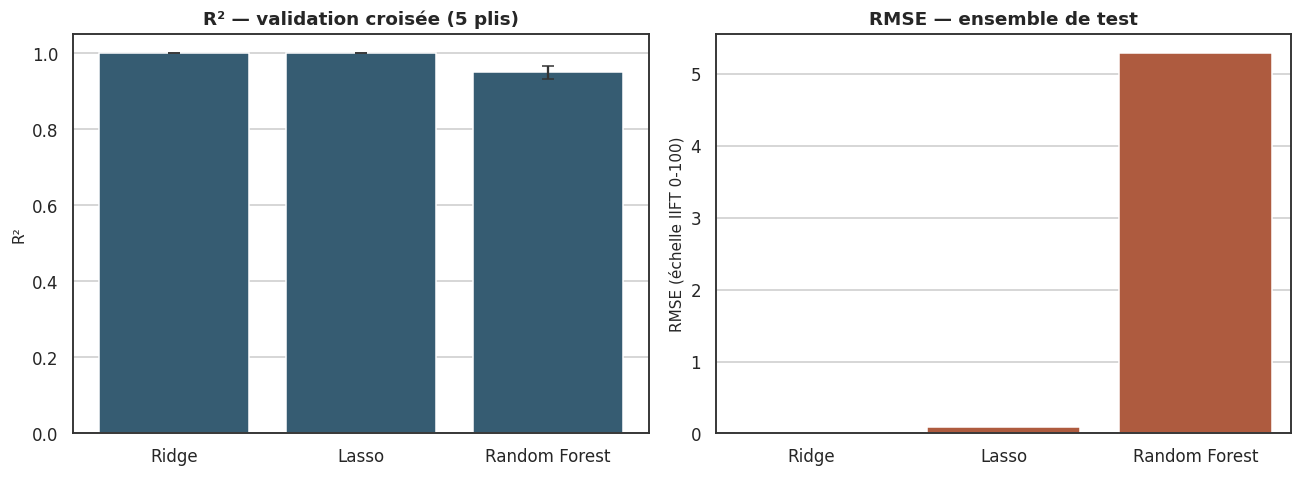

In [9]:
# ===========================================================================
#  SECTION 9 (Cellule 19) — COMPARAISON DES MODÈLES
# ===========================================================================

print("=" * 65)
print("  SECTION 9 — COMPARAISON DES MODÈLES")
print("=" * 65)

comparaison_modeles = pd.DataFrame([
    {"modele": "Ridge", "R2_train": metriques_ridge_train["R2"], "R2_test": metriques_ridge_test["R2"],
     "RMSE_test": metriques_ridge_test["RMSE"], "MAE_test": metriques_ridge_test["MAE"],
     "R2_CV_moyen": scores_cv_ridge.mean(), "R2_CV_ecart_type": scores_cv_ridge.std()},
    {"modele": "Lasso", "R2_train": metriques_lasso_train["R2"], "R2_test": metriques_lasso_test["R2"],
     "RMSE_test": metriques_lasso_test["RMSE"], "MAE_test": metriques_lasso_test["MAE"],
     "R2_CV_moyen": scores_cv_lasso.mean(), "R2_CV_ecart_type": scores_cv_lasso.std()},
    {"modele": "Random Forest", "R2_train": metriques_rf_train["R2"], "R2_test": metriques_rf_test["R2"],
     "RMSE_test": metriques_rf_test["RMSE"], "MAE_test": metriques_rf_test["MAE"],
     "R2_CV_moyen": scores_cv_rf.mean(), "R2_CV_ecart_type": scores_cv_rf.std()},
]).round(4)

display(comparaison_modeles)

# Écart train/test = signal de surapprentissage (attendu très faible pour Ridge/Lasso,
# à surveiller davantage pour Random Forest si max_depth n'est pas contraint)
comparaison_modeles["ecart_train_test"] = (comparaison_modeles["R2_train"] - comparaison_modeles["R2_test"]).round(4)
print("\nÉcart R² train − test (surapprentissage si élevé) :")
display(comparaison_modeles[["modele", "ecart_train_test"]])

fig, axes_plot = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=comparaison_modeles, x="modele", y="R2_CV_moyen",
            color=COULEUR_PRINCIPALE, ax=axes_plot[0])
axes_plot[0].errorbar(
    x=range(len(comparaison_modeles)), y=comparaison_modeles["R2_CV_moyen"],
    yerr=comparaison_modeles["R2_CV_ecart_type"], fmt="none", color="#333333", capsize=4,
)
axes_plot[0].set_title("R² — validation croisée (5 plis)")
axes_plot[0].set_ylabel("R²")
axes_plot[0].set_xlabel("")
axes_plot[0].set_ylim(0, 1.05)

sns.barplot(data=comparaison_modeles, x="modele", y="RMSE_test", color=COULEUR_ACCENT, ax=axes_plot[1])
axes_plot[1].set_title("RMSE — ensemble de test")
axes_plot[1].set_ylabel("RMSE (échelle IIFT 0-100)")
axes_plot[1].set_xlabel("")

plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_modelisation_comparaison_modeles.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 10 (Cellule 20) — Comparaison des importances de variables (Ridge / Lasso / RF / ACP)

C'est le cœur analytique de cette phase (cf. Section 3, point 4) : si une variable ressort comme
importante selon **plusieurs méthodes indépendantes** (linéaire régularisée, arbre, et la contribution
factorielle de l'ACP elle-même), c'est un argument de robustesse solide pour le rapport — bien plus
convaincant qu'une seule méthode.

Chaque colonne est normalisée en **% du total** (les 4 méthodes ont des échelles natives différentes :
coefficients standardisés, importance Gini, score de permutation, contribution ACP en %) pour permettre
une comparaison directe.


  SECTION 10 — COMPARAISON DES IMPORTANCES DE VARIABLES
Référence d'équi-répartition : 4.17% (si les 24 variables comptaient à égalité)


,ridge_pct,lasso_pct,rf_impurete_pct,rf_permutation_pct,acp_dim1_pct,moyenne_4_methodes
nb_types_services,6.22,6.47,33.33,50.81,7.88,20.94
brh_banque,6.50,6.47,27.32,16.92,8.00,13.04
brh_maison_de_transfert,6.55,7.10,5.92,7.96,8.44,7.19
brh_agent_non_bancaire,6.12,7.01,5.22,3.46,7.45,5.85
taux_epargne_formelle,4.74,4.97,7.70,7.04,4.36,5.76
brh_atm,6.41,6.64,3.73,3.43,7.50,5.54
brh_microfinance,6.36,6.48,2.27,0.85,7.55,4.70
part_urbaine,5.64,5.70,3.72,2.28,6.01,4.67
population_totale,5.59,5.98,1.79,1.40,5.90,4.13
superficie_urbaine_km2,5.51,5.59,0.99,2.02,6.13,4.05


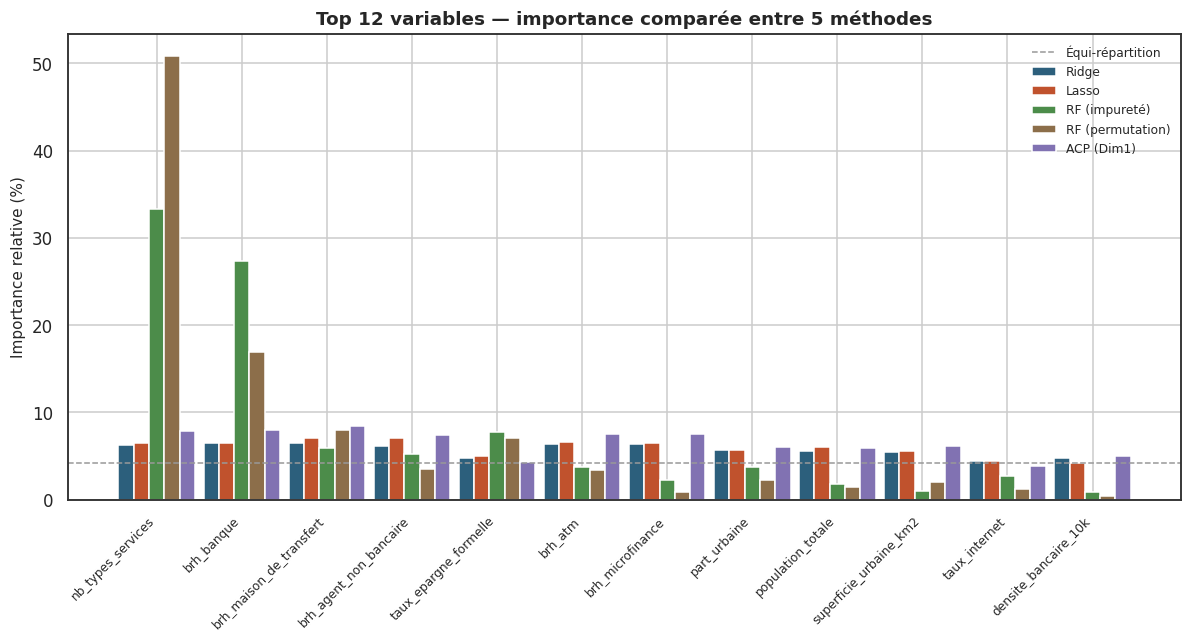

In [10]:
# ===========================================================================
#  SECTION 10 (Cellule 21) — COMPARAISON DES IMPORTANCES DE VARIABLES
# ===========================================================================

print("=" * 65)
print("  SECTION 10 — COMPARAISON DES IMPORTANCES DE VARIABLES")
print("=" * 65)

# ── Contribution ACP à Dim1 (Phase 2.2), déjà en % — on l'aligne sur vars_acp ──
contrib_dim1_acp = (
    contrib_acp.set_index("variable")["Dim1"]
    if "Dim1" in contrib_acp.columns
    else contrib_acp.set_index("variable").iloc[:, 0]
).reindex(vars_acp).fillna(0)

def normaliser_en_pourcentage(serie):
    valeurs_abs = serie.abs()
    return (100 * valeurs_abs / valeurs_abs.sum()).round(2)

importance_comparee = pd.DataFrame({
    "ridge_pct":       normaliser_en_pourcentage(coefficients_ridge.reindex(vars_acp)),
    "lasso_pct":       normaliser_en_pourcentage(coefficients_lasso.reindex(vars_acp)),
    "rf_impurete_pct": normaliser_en_pourcentage(importance_impurete_rf.reindex(vars_acp)),
    "rf_permutation_pct": normaliser_en_pourcentage(importance_permutation_rf.reindex(vars_acp)),
    "acp_dim1_pct":    normaliser_en_pourcentage(contrib_dim1_acp),
})
importance_comparee["moyenne_4_methodes"] = importance_comparee.mean(axis=1).round(2)
importance_comparee = importance_comparee.sort_values("moyenne_4_methodes", ascending=False)

print(f"Référence d'équi-répartition : {100 / len(vars_acp):.2f}% (si les {len(vars_acp)} variables comptaient à égalité)")
display(importance_comparee)

# ── Visualisation : top 12 variables, barres groupées par méthode ───────────
top12 = importance_comparee.head(12)
fig, ax = plt.subplots(figsize=(11, 6))
largeur = 0.18
positions = np.arange(len(top12))
methodes = ["ridge_pct", "lasso_pct", "rf_impurete_pct", "rf_permutation_pct", "acp_dim1_pct"]
couleurs_methodes = [COULEUR_PRINCIPALE, COULEUR_ACCENT, COULEUR_RF, "#8C6E4A", COULEUR_ACP]
labels_methodes = ["Ridge", "Lasso", "RF (impureté)", "RF (permutation)", "ACP (Dim1)"]

for i, (col, couleur, label) in enumerate(zip(methodes, couleurs_methodes, labels_methodes)):
    ax.bar(positions + i * largeur, top12[col], width=largeur, color=couleur, label=label)

ax.set_xticks(positions + largeur * 2)
ax.set_xticklabels(top12.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Importance relative (%)")
ax.set_title("Top 12 variables — importance comparée entre 5 méthodes")
ax.axhline(100 / len(vars_acp), linestyle="--", color="#999999", linewidth=1, label="Équi-répartition")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_modelisation_importance_variables_comparee.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 11 (Cellule 22) — Prédit vs réel (diagnostic visuel)


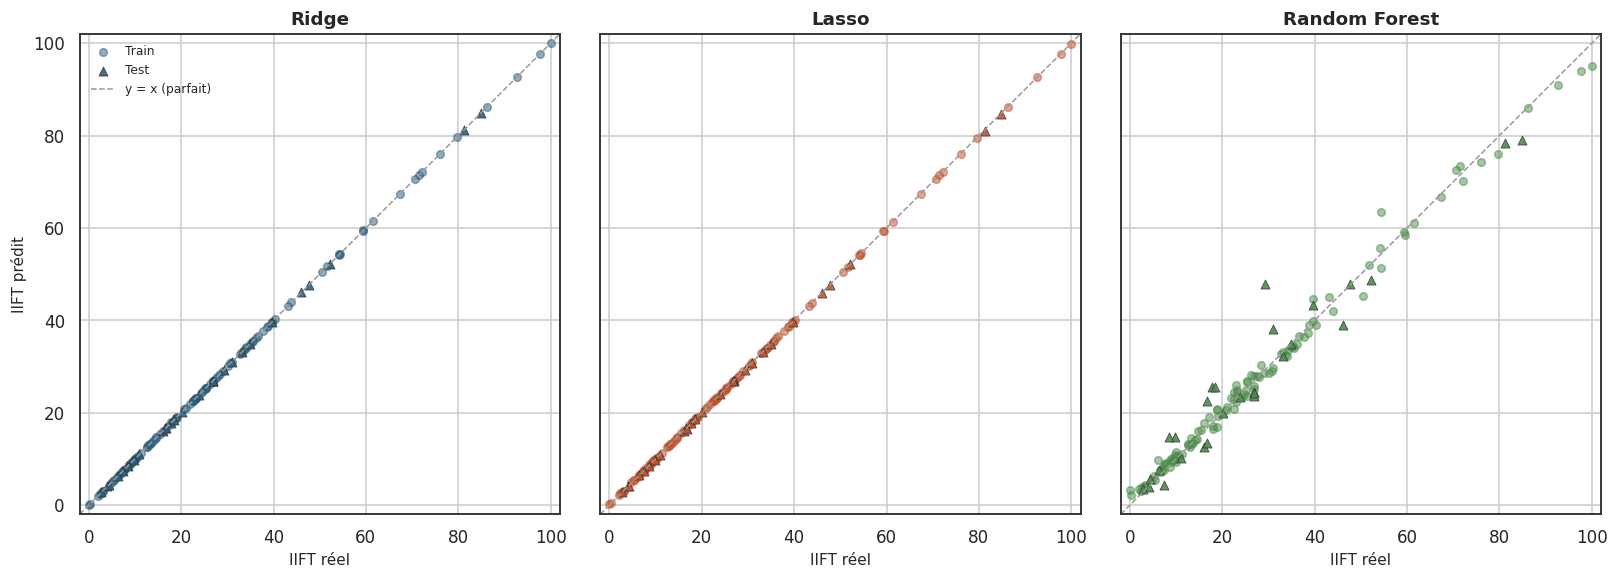

In [11]:
# ===========================================================================
#  SECTION 11 (Cellule 23) — PRÉDIT VS RÉEL
# ===========================================================================

fig, axes_plot = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

modeles_pred = [
    ("Ridge", pred_train_ridge, pred_test_ridge, COULEUR_PRINCIPALE),
    ("Lasso", pred_train_lasso, pred_test_lasso, COULEUR_ACCENT),
    ("Random Forest", pred_train_rf, pred_test_rf, COULEUR_RF),
]

for ax, (nom, pred_train, pred_test, couleur) in zip(axes_plot, modeles_pred):
    ax.scatter(y_train, pred_train, alpha=0.5, s=25, color=couleur, label="Train")
    ax.scatter(y_test, pred_test, alpha=0.9, s=35, color=couleur, marker="^",
               edgecolor="#333333", linewidth=0.5, label="Test")
    lims = [min(y.min(), 0) - 2, max(y.max(), 100) + 2]
    ax.plot(lims, lims, linestyle="--", color="#999999", linewidth=1, label="y = x (parfait)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(nom)
    ax.set_xlabel("IIFT réel")

axes_plot[0].set_ylabel("IIFT prédit")
axes_plot[0].legend(fontsize=8, frameon=False, loc="upper left")

plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_modelisation_predit_vs_reel.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 12 (Cellule 24) — Exports (tables + figures HD)

Les tables sont enregistrées dans `output/tables/modelisation_tables/` et les figures HD (300 dpi) dans
`output/figures/`, comme dans les notebooks précédents. Un zip des figures est créé et, sous Colab,
toutes les tables (CSV) et le zip de figures sont proposés en téléchargement automatique.
Pour les rendre disponibles sur GitHub, il faudra ensuite les ajouter dans
`output/tables/modelisation_tables`, committer et pousser dans le dépôt.


In [12]:
# ===========================================================================
#  SECTION 12 (Cellule 25) — EXPORTS
# ===========================================================================

print("=" * 65)
print("  SECTION 12 — EXPORTS")
print("=" * 65)

# ── Table des prédictions par commune, tous modèles confondus ───────────────
predictions_communes = donnees[cols_id + ["IIFT", "classe_IIFT"]].copy()
predictions_communes["IIFT_predit_ridge"] = np.nan
predictions_communes["IIFT_predit_lasso"] = np.nan
predictions_communes["IIFT_predit_rf"] = np.nan
predictions_communes.loc[idx_train, "IIFT_predit_ridge"] = pred_train_ridge
predictions_communes.loc[idx_test,  "IIFT_predit_ridge"] = pred_test_ridge
predictions_communes.loc[idx_train, "IIFT_predit_lasso"] = pred_train_lasso
predictions_communes.loc[idx_test,  "IIFT_predit_lasso"] = pred_test_lasso
predictions_communes.loc[idx_train, "IIFT_predit_rf"] = pred_train_rf
predictions_communes.loc[idx_test,  "IIFT_predit_rf"] = pred_test_rf
predictions_communes["ensemble"] = "train"
predictions_communes.loc[idx_test, "ensemble"] = "test"

exports = {
    "G10_modelisation_comparaison_modeles.csv": comparaison_modeles,
    "G10_modelisation_importance_variables.csv": importance_comparee.reset_index().rename(columns={"index": "variable"}),
    "G10_modelisation_predictions_communes.csv": predictions_communes,
    "G10_modelisation_variables_lasso_retirees.csv": tbl_variables_lasso_retirees,
}

for nom_fichier, table in exports.items():
    chemin = DOSSIER_TABLES / nom_fichier
    table.to_csv(chemin, index=False, encoding="utf-8-sig")
    print(f"✅ {nom_fichier} exporté — {table.shape[0]} lignes × {table.shape[1]} colonnes")

print()
print("✅ Exports terminés dans output/tables/modelisation_tables")

# ── Export HD (zip) de toutes les figures générées ──────────────────────────
import shutil

fichiers_figures = sorted(DOSSIER_FIGURES.glob("G10_modelisation_*.png"))
print(f"\n📊 {len(fichiers_figures)} figure(s) HD (300 dpi) trouvée(s) dans '{DOSSIER_FIGURES}/'")

if fichiers_figures:
    chemin_zip_base = "G10_Modelisation_figures_HD"
    # Zippe un dossier temporaire ne contenant que les figures de CE notebook
    # (DOSSIER_FIGURES est partagé avec les notebooks EDA/ACP précédents)
    dossier_tmp_figures = Path("_tmp_figures_modelisation")
    dossier_tmp_figures.mkdir(exist_ok=True)
    for f in fichiers_figures:
        shutil.copy(f, dossier_tmp_figures / f.name)
    chemin_zip = shutil.make_archive(chemin_zip_base, "zip", dossier_tmp_figures)
    shutil.rmtree(dossier_tmp_figures)
    taille_mo = os.path.getsize(chemin_zip) / (1024 * 1024)
    print(f"✅ {chemin_zip} créé ({taille_mo:.1f} Mo, {len(fichiers_figures)} image(s))")
else:
    chemin_zip = None
    print("⚠️ Aucune figure trouvée — relancez les sections avec graphiques avant cette cellule.")

# ── Téléchargement automatique sous Colab (tables + zip de figures) ─────────
if IN_COLAB:
    from google.colab import files
    for nom_fichier in exports:
        files.download(str(DOSSIER_TABLES / nom_fichier))
    if chemin_zip:
        files.download(chemin_zip)
    print("\n✅ Téléchargements Colab lancés (tables CSV + zip de figures)")
else:
    print(f"\nℹ️ Hors Colab : récupérez directement les fichiers dans '{DOSSIER_TABLES}/', "
          f"'{DOSSIER_FIGURES}/'" + (f" (ou le zip '{chemin_zip}')" if chemin_zip else ""))


  SECTION 12 — EXPORTS
✅ G10_modelisation_comparaison_modeles.csv exporté — 3 lignes × 8 colonnes
✅ G10_modelisation_importance_variables.csv exporté — 24 lignes × 7 colonnes
✅ G10_modelisation_predictions_communes.csv exporté — 140 lignes × 10 colonnes
✅ G10_modelisation_variables_lasso_retirees.csv exporté — 1 lignes × 1 colonnes

✅ Exports terminés dans output/tables/modelisation_tables

📊 3 figure(s) HD (300 dpi) trouvée(s) dans 'output/figures/'
✅ /content/G10_Modelisation_figures_HD.zip créé (0.6 Mo, 3 image(s))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Téléchargements Colab lancés (tables CSV + zip de figures)


---
## Section 13 (Cellule 26) — Synthèse méthodologique pour le rapport


In [13]:
# ===========================================================================
#  SECTION 13 (Cellule 27) — SYNTHÈSE POUR LE RAPPORT
# ===========================================================================

meilleur_modele = comparaison_modeles.loc[comparaison_modeles["R2_CV_moyen"].idxmax(), "modele"]
top5_variables = importance_comparee.head(5).index.tolist()

resume_methodo = f"""
Synthèse méthodologique — Modélisation supervisée & Feature Importance (Phase 2.5)

1. Les {len(vars_acp)} variables quantitatives actives (mêmes que la Phase 2.2, ACP) ont été utilisées
   comme prédicteurs (X) pour reconstruire l'IIFT (y), sur {X.shape[0]} communes.
2. Un split train/test stratifié (80/20) et une validation croisée à 5 plis ont été combinés pour une
   estimation robuste de la performance, malgré la taille limitée de l'échantillon (140 communes).
3. Ridge (R² CV = {scores_cv_ridge.mean():.3f}) et Lasso (R² CV = {scores_cv_lasso.mean():.3f}) atteignent,
   comme attendu (cf. Section 3), un score quasi parfait — confirmation que l'IIFT est bien une fonction
   linéaire de ces variables, cohérent avec sa construction par ACP en Phase 2.2.
4. Lasso a ramené à zéro {len(variables_retirees_lasso)} variable(s) sur {len(vars_acp)}, identifiant un
   sous-ensemble parcimonieux suffisant pour reconstruire l'IIFT : {variables_conservees_lasso}.
5. Le Random Forest (R² CV = {scores_cv_rf.mean():.3f}) obtient une performance {"similaire à" if abs(scores_cv_rf.mean() - scores_cv_ridge.mean()) < 0.03 else "différente de"}
   celle des modèles linéaires, ce qui {"confirme" if abs(scores_cv_rf.mean() - scores_cv_ridge.mean()) < 0.03 else "interroge"}
   l'hypothèse de linéarité sous-jacente à la construction de l'IIFT.
6. Les 5 variables les plus importantes, tous critères combinés (Ridge, Lasso, RF-impureté,
   RF-permutation, contribution ACP à Dim1), sont : {top5_variables}.
7. Le modèle {meilleur_modele} (meilleur R² en validation croisée) peut être conservé comme calculateur
   rapide de l'IIFT pour des données futures, sans avoir à refaire l'ACP complète.
8. ⚠️ Rappel pour la rédaction : le R² élevé de cette phase valide la construction de l'IIFT, il ne
   constitue pas une performance prédictive "hors échantillon" au sens classique (cf. Section 3).
"""

print(resume_methodo)



Synthèse méthodologique — Modélisation supervisée & Feature Importance (Phase 2.5)

1. Les 24 variables quantitatives actives (mêmes que la Phase 2.2, ACP) ont été utilisées
   comme prédicteurs (X) pour reconstruire l'IIFT (y), sur 140 communes.
2. Un split train/test stratifié (80/20) et une validation croisée à 5 plis ont été combinés pour une
   estimation robuste de la performance, malgré la taille limitée de l'échantillon (140 communes).
3. Ridge (R² CV = 1.000) et Lasso (R² CV = 1.000) atteignent,
   comme attendu (cf. Section 3), un score quasi parfait — confirmation que l'IIFT est bien une fonction
   linéaire de ces variables, cohérent avec sa construction par ACP en Phase 2.2.
4. Lasso a ramené à zéro 1 variable(s) sur 24, identifiant un
   sous-ensemble parcimonieux suffisant pour reconstruire l'IIFT : ['brh_maison_de_transfert', 'brh_agent_non_bancaire', 'brh_atm', 'brh_microfinance', 'nb_types_services', 'brh_banque', 'population_totale', 'part_urbaine', 'superficie_urba